In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from microlens.jlu import multinest_utils
from bagle import model_fitter

In [4]:
# Fontsize
plt.rc('font', size=17)

# Default matplotlib color cycles.
mpl_b = '#1f77b4'
mpl_o = '#ff7f0e'
mpl_g = '#2ca02c'
mpl_r = '#d62728'

In [5]:
phot_ast_fits = {'MB09260' : '/u/jlu/work/microlens/MB09260/a_2021_09_19/model_fits/moa_hst_phot_ast_gp/base_a/a0_',
                 'MB09260_split' : '/u/jlu/work/microlens/MB09260/a_2021_09_19/model_fits/moa_hst_phot_ast_gp/base_a/a0_split_',
                 'MB10364' : '/u/jlu/work/microlens/MB10364/a_2021_09_19/model_fits/moa_hst_phot_ast_adderr/base_a/a0_', # NO GP, TEMPORARY              
                 'OB110037' : '/u/jlu/work/microlens/OB110037/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_',
                 'OB110310' : '/u/jlu/work/microlens/OB110310/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_',
                 'OB110310_split' : '/u/jlu/work/microlens/OB110310/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_split_',
                 'OB110462_el' : '/u/jlu/work/microlens/OB110462/a_2021_12_28/model_fits/ogle_hst_phot_ast/pspl/fixed_weight/a0_', # EQUAL LIKELIHOOD    
                 'OB110462_p' : '/u/jlu/work/microlens/OB110462/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/u0p_En_Nn/a0_',
                 'OB110462_new_dw_ast' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/hst_ast/base_a/a0_',
                 #'MB19284' : '/g2/scratch/jlu/microlens/MB19284/a_2024_08_29/model_fit/BSPL_base_a0_allDATA_Hobson_Weighted_noOM_dragon/a0_'
                 'MB19284' : '/g2/scratch/jlu/microlens/MB19284/a_2024_08_29/model_fit/BSPL_base_a0_allDATA_Hobson_Weighted_noOM_dragon/a0_'
                }
# From reanalysis
phot_fits = {'OB110462' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/ogle_hst_phot_gp/base_a/a0_'} # nominal fits                              
ast_fits = {'OB110462' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/hst_ast/base_a/a0_'}

mdir = '/u/jlu/work/microlens/'
mg2dir = '/g2/scratch/jlu/microlens/'
phot_2020_dir = {'kb200101' : mg2dir + 'KB200101/a_2025_09_10/model_fits/run_pspl_par_k_plot_things/',
                 'mb19284' : mdir + '',
                 'ob190017' : mg2dir + 'OB190017/a_2025_09_17/a0_',
                 'ob170019' : mg2dir + 'OB170019/a_2025_09_17/a0_', 
                 'ob170095' : mg2dir +  'OB170095/a_2025_09_17/a0_',
                 'ob230215' : '/u/mhuston/code/MAD/bagle_fits/OB230215/fits_2024_09_27/pspl_phot_par/b0_',
                 'ob240062' : '/u/mhuston/code/MAD/bagle_fits/OB240062/fits_2024_09_25/pspl_phot_par/b0_'}

In [6]:
# run directory
ob120169_dir = '/u/jlu/work/microlens/OB120169/a_2023_12_05/model_fits/120_phot_astrom_adderr/'
ob140613_dir = '/u/jlu/work/microlens/OB140613/a_2024_04_02/model_fits/phot_astro_EW/'
ob150029_dir = '/u/jlu/work/microlens/OB150029/a_2023_12_12/model_fits/120_fit_phot_astrom_parallax_aerr_ogle_keck/base_a/'
ob150211_dir = '/u/jlu/work/microlens/OB150211/a_2023_12_12/model_fits/120_phot_astrom_parallax_aerr_ogle_keck/'

# run id
ob120169_id = 'a1'
ob140613_id = 'a1'
ob150029_id = 'a1'
ob150211_id = 'a1'

mod_roots = {'ob120169': ob120169_dir + ob120169_id + '_',
             'ob140613': ob140613_dir + ob140613_id + '_',
             'ob150029': ob150029_dir + ob150029_id + '_',
             'ob150211': ob150211_dir + ob150211_id + '_',
             'mb19284':  phot_ast_fits['MB19284']}

In [7]:
pspl_ast_multiphot = {'ob120169': ob120169_dir + ob120169_id + '_',
             'ob140613': ob140613_dir + ob140613_id + '_',
             'ob140613_alt': ob140613_dir + ob140613_id + '_',
             'ob150029': ob150029_dir + ob150029_id + '_',
             'ob150211': ob150211_dir + ob150211_id + '_'}
pspl_ast_multiphot_mode = {'ob120169': 0,
                           'ob140613': 0,
                           'ob140613_alt': 1,
                           'ob150029': 0,
                           'ob150211': 0}

***** WARNING: PHOTOMETRY DATA WILL NOT BE FIT BY <class 'bagle.model.PSPL_Astrom_Par_Param3'> *****


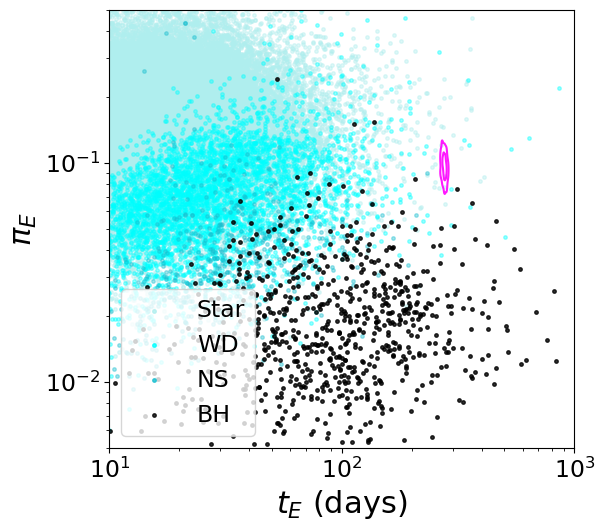

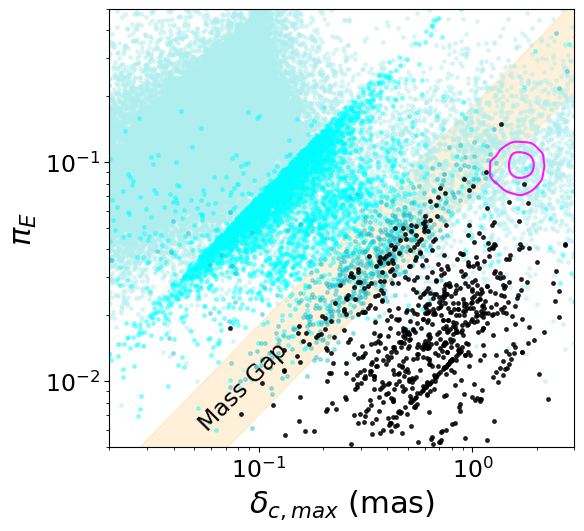

In [20]:
def piE_tE(fit_type = 'ast'):
    """
    Supports plotting for several different fit solutions:

    fit_type = 'ast'
        Keck + OGLE photometry, Keck astrometry
    fit_type = 'phot'
        OGLE photometry
    fit_type = 'multiphot'
        Keck + OGLE photometry
    """
    piE_tE_textsize = 22
    
    if fit_type == 'ast':
        data_dict = mod_roots
    if fit_type == 'phot':
        data_dict = lu_2019_lens.pspl_phot
    if fit_type == 'multiphot':
        data_dict = lu_2019_lens.pspl_multiphot

    ##########
    # !!! NOTE: CHOICE OF THE quantiles_2d HAS A LARGE EFFECT 
    # ON THE WAY THIS PLOT LOOKS !!!
    # Plot piE-tE 2D posteriors from OGLE photometry only fits.
    # Also plot PopSyCLE simulations simultaneously.
    ##########
    span = 0.999999426697
    smooth = 0.04
    quantiles_2d = None
    hist2d_kwargs = None
    labels = None
    label_kwargs = None
    show_titles = False 
    title_fmt = ".2f" 
    title_kwargs = None
    
    # Initialize values.
    if label_kwargs is None:
        label_kwargs = dict()
    if title_kwargs is None:
        title_kwargs = dict()
    if hist2d_kwargs is None:
        hist2d_kwargs = dict()

    # Dictionary of dictionaries containing the tE and piE
    # label position for each of the text labels.
    # WARNING: THE 'PHOT' AND 'AST' ARE THE SAME FOR THE NEW
    # TARGETS... THEY ARE JUST PHOT THOUGH.
    label_pos = {'phot': {'ob120169': [150, 0.01],
                          'ob140613': [170, 0.1],
                          'ob150029': [150, 0.2],
                          'ob150211': [35, 0.04],
                          'ob170019': [0, 0.04],
                          'ob170095': [0, 0.04],
                          'ob190017': [0, 0.04],
                          'kb200101': [0, 0],
                          'ob230215': [400, 0.1],
                          'ob240062': [220, 0.03]},
                 'ast':  {'ob120169': [45, 0.12],
                          'ob140613': [250, 0.16],
                          'ob150029': [40, 0.22],
                          'ob150211': [140, 0.01],
                          'ob170019': [120, 0.045],
                          'ob170095': [30, 0.04],
                          'ob190017': [70, 0.21],
                          'kb200101': [120, 0.06],
                          'MB19284' : [340, 0.08],
                          'ob230215': [420, 0.115],
                          'ob240062': [220, 0.025]}}

    label_pos_ast = {'ob120169': [0.006, 0.06],
                     'ob140613': [0.04, 0.145],
                     'ob150029': [0.02, 0.25],
                     'ob150211': [0.03, 0.012]}

    colors = {'ob120169': 'blue',
              'ob140613': 'blue',
              'ob140613_alt': 'orange',
              'ob150029': 'blue',
              'ob150211': 'blue',
              'ob170019': 'blue',
              'ob170095': 'blue',
              'ob190017': 'green',
              'kb200101': 'green',
              'ob230215': 'green',
              'ob240062': 'green',
              'MB09260' : 'gray',
              'MB10364' : 'gray',
              'OB110037' : 'gray',
              'OB110310' : 'gray',
              'OB110462' : 'magenta',
              'MB19284': 'green'}

    #manual_pts = {}

    # Set defaults.
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    hist2d_kwargs['levels'] = hist2d_kwargs.get('levels', quantiles_2d)

#    model_fitter.contour2d_alpha(data['tE'], data['piE'], span=[span, span], quantiles_2d=quantiles_2d,
#                                 ax=axes, smooth=[sy, sx], color='blue',
#                                 **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
#    axes.text(300, 0.025, 'MB19284', color='blue')


    targets = []#'ob120169', 'ob140613', 'ob150029', 'ob150211'] #'ob140613_alt',
    hst_targets = ['OB110462']#'MB09260', 'MB10364', 'OB110037', 'OB110310', 'OB110462']
    new_targets = []#'ob170019', 'ob170095', 'ob190017', 'kb200101', 'ob230215','ob240062']
    label_targets = [] #'ob230215', 'ob240062', 'ob190017', 'kb200101'] #, 'OB110462']
    tE = {}
    piE = {}
    theta_E = {}
    weights = {}

    for targ in hst_targets: #+ ['MB19284']:
        if targ == 'OB110462':
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(ast_fits['OB110462'])
        else:
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(phot_ast_fits[targ])

        res_targ = fit_targ.load_mnest_results()

        tE[targ] = res_targ['tE']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        theta_E[targ] = 10**res_targ['log10_thetaE']
        weights[targ] = res_targ['weights']

    for targ in targets:
        fitter, data = lu_2019_lens.get_data_and_fitter(pspl_ast_multiphot[targ])
        #fitter.separate_modes()
#        stats_ast, data_ast, mod_ast = lu_2019_lens.load_summary_statistics(lu_2019_lens.pspl_ast_multiphot[targ])
        tab_list = fitter.load_mnest_modes()
        mode = pspl_ast_multiphot_mode[targ]
        fit_targ, dat_targ = multinest_utils.get_data_and_fitter(pspl_ast_multiphot[targ])

        res_targ = tab_list[mode]
        
#        res_targ = fit_targ.load_mnest_results(remake_fits=True)
#        res_targ = fit_targ.load_mnest_modes()
#        res_targ = res_targ[0]
#
        tE[targ] = res_targ['tE']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        try:
            theta_E[targ] = res_targ['thetaE_amp']
        except:
            theta_E[targ] = res_targ['thetaE']
        weights[targ] = res_targ['weights']

    for targ in new_targets:
        fit_targ, dat_targ = lu_2019_lens.get_data_and_fitter(phot_2020_dir[targ])
        
        res_targ = fit_targ.load_mnest_modes()
        smy_targ = fit_targ.load_mnest_summary()

        # Get rid of the global mode in the summary table.
        smy_targ = smy_targ[1:]

        # Find which solution has the max likelihood.
        mdx = smy_targ['maxlogL'].argmax()
        res_targ = res_targ[0]
        smy_targ = smy_targ
        tE[targ] = res_targ['tE']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        weights[targ] = res_targ['weights']

    # Plot the piE-tE 2D posteriors.
#    plt.close(1)
    fig = plt.figure(1, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)
    sx = smooth
    sy = smooth

    hist2d_kwargs['fill_contours'] = hist2d_kwargs.get('fill_contours', False)
    hist2d_kwargs['plot_contours'] = hist2d_kwargs.get('plot_contours', True)

    for targ in targets + new_targets: #+ ['MB09260', 'MB10364', 'OB110037', 'OB110310', 'MB19284']:
        model_fitter.contour2d_alpha(tE[targ], piE[targ], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights[targ], ax=axes, smooth=[sy, sx], color=colors[targ],
                                     **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
        if targ[:4]=='ob14' or targ=='ob230215':
            print(targ, np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]))
            #manual_pts[targ] = (np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]))
            plt.plot(np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]), 'o', color=colors[targ])

        
    hist2d_kwargs['plot_contours'] = hist2d_kwargs.get('plot_contours',
                                                       False)
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    model_fitter.contour2d_alpha(tE['OB110462'], piE['OB110462'], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights['OB110462'], ax=axes, smooth=[sy, sx], color=colors['OB110462'],
                                 contour_kwargs={'alpha' : 0.9}, plot_density=False, sigma_levels=[1, 2])

    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.2)


    for targ in label_targets: #+ ['MB19284']:
        axes.text(label_pos[fit_type][targ][0], label_pos[fit_type][targ][1],
                      targ.upper(), color=colors[targ], ha='left')

    t = Table.read('/u/nsabrams/work/roman/PopSyCLE/2025_tables/events_fields_in_progress.fits')
    lmag = t['roman_f146_app_L']
    smag = t['roman_f146_app_S']
    

    bh_idx = np.where(t['rem_id_L'] == 103)[0]
    ns_idx = np.where(t['rem_id_L'] == 102)[0]
    wd_idx = np.where(t['rem_id_L'] == 101)[0]
    st_idx = np.where(t['rem_id_L'] == 0)[0]

    u0_arr = t['u0']
    thetaE_arr = t['theta_E']
    # Stores the maximum astrometric shift
    final_delta_arr = np.zeros(len(u0_arr))
    
    # Stores the lens-source separation corresponding
    # to the maximum astrometric shift
    final_u_arr = np.zeros(len(u0_arr))

    # Sort by whether the maximum astrometric shift happens
    # before or after the maximum photometric amplification
    big_idx = np.where(u0_arr > np.sqrt(2))[0]
    small_idx = np.where(u0_arr <= np.sqrt(2))[0]

    # Flux ratio of lens to source (and make it 0 if dark lens)
    g_arr = 10**(-0.4 * (lmag - smag))
    g_arr = np.nan_to_num(g_arr.filled(np.nan))

    for i in np.arange(len(u0_arr)):
        g = g_arr[i] 
        thetaE = thetaE_arr[i]    
        # Try all values between u0 and sqrt(2) to find max 
        # astrometric shift
        if u0_arr[i] < np.sqrt(2):
            u_arr = np.linspace(u0_arr[i], np.sqrt(2), 100)
            delta_arr = np.zeros(len(u_arr))
            for j in np.arange(len(u_arr)):
                u = u_arr[j] 
                numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
                denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
                delta = (u * thetaE/(1 + g)) * (numer/denom)
                delta_arr[j] = delta
            max_idx = np.argmax(delta_arr)
            final_delta_arr[i] = delta_arr[max_idx]
            final_u_arr[i] = u_arr[max_idx]
        # Maximum astrometric shift will occur at sqrt(2)
        if u0_arr[i] > np.sqrt(2):
            u = u0_arr[i]
            numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
            denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
            delta = (u * thetaE/(1 + g)) * (numer/denom)
            final_delta_arr[i] = delta
            final_u_arr[i] = u

    axes.scatter(t['t_E'][st_idx], t['pi_E'][st_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'paleturquoise')
    axes.scatter(t['t_E'][wd_idx], t['pi_E'][wd_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'aqua')
    axes.scatter(t['t_E'][ns_idx], t['pi_E'][ns_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'tab:cyan')
    axes.scatter(t['t_E'][bh_idx], t['pi_E'][bh_idx],
                 alpha = 0.8, marker = '.', s = 25, 
                 color = 'black')

    # Trickery to make the legend darker
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'Star', color = 'paleturquoise')
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25,
                 label = 'WD', color = 'aqua')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'NS', color = 'tab:cyan')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'BH', color = 'black')

    axes.set_xlim(10, 1000)
    axes.set_ylim(0.005, 0.5)
    axes.set_xlabel('$t_E$ (days)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.legend(loc=3)
    plt.show()
    plt.savefig('piE_tE_roman_cycle1.png', bbox_inches='tight')
    plt.close()

    # Plot the deltac-piE 2D posteriors.
#    plt.close(2)
    fig = plt.figure(2, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)

    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    

    model_fitter.contour2d_alpha(theta_E['OB110462']/np.sqrt(8), piE['OB110462'], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights['OB110462'], ax=axes, smooth=[sy, sx], color=colors['OB110462'],
                                 contour_kwargs={'alpha' : 0.9}, plot_density=False, sigma_levels=[1, 2])
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.2)
 

    xarr = np.linspace(0.001, 4, 1000)
    axes.fill_between(xarr, xarr*0.18, xarr*0.07, alpha=0.15, color='orange')
    axes.text(0.05, 0.006, 'Mass Gap', rotation=45)

    axes.scatter(final_delta_arr[st_idx], t['pi_E'][st_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'paleturquoise')
    axes.scatter(final_delta_arr[wd_idx], t['pi_E'][wd_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'aqua')
    axes.scatter(final_delta_arr[ns_idx], t['pi_E'][ns_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'tab:cyan')
    axes.scatter(final_delta_arr[bh_idx], t['pi_E'][bh_idx], 
                  alpha = 0.8, marker = '.', s = 25,
                  c = 'black')

    axes.set_xlabel('$\delta_{c,max}$ (mas)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.set_xlim(0.02, 3)
    axes.set_ylim(0.005, 0.5)
    plt.show()
    plt.savefig('piE_deltac_roman_cycle1.png', bbox_inches='tight')
    plt.show()
piE_tE()